<a href="https://colab.research.google.com/github/jurados/alercehackton2026/blob/jurados/Crosmatch_lsst_ztf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors

In [3]:
%%capture
!pip install alerce pyvo

In [4]:
from alerce.core import Alerce
import pyvo as vo

from astropy.timeseries import LombScargle
from astropy.coordinates import SkyCoord
import astropy.units as u

alerce_client = Alerce()

def mag2fluxnjy(mag):
    return 10 ** (-(mag - 31.4) / 2.5)

def mag_err_2_fluxnjy_err(mag_err, mag):
    return np.log(10.0) * mag2fluxnjy(mag) / 2.5 * mag_err

def fluxnjy2mag(flux):
    return 31.4 - 2.5 * np.log10(flux)

def flux_err_2_mag_err(flux_err, flux):
    return (2.5 * flux_err) / (np.log(10.0) * flux)

In [ ]:
df = alerce_client.query_objects(
    survey="ztf",
    #classifier="lc_classifier_BHRF_forced_phot",
    classifier="lc_classifier",
    class_name="SNIa",
    probability=0.50,
    order_by="probability",
    order_mode="DESC",
    page_size=2000,
    format="pandas"
)
df.shape, df.oid.nunique(), df.columns, df.head()

((2000, 23),
 1994,
 Index(['oid', 'ndethist', 'ncovhist', 'mjdstarthist', 'mjdendhist',
        'corrected', 'stellar', 'ndet', 'g_r_max', 'g_r_max_corr', 'g_r_mean',
        'g_r_mean_corr', 'firstmjd', 'lastmjd', 'deltajd', 'meanra', 'meandec',
        'sigmara', 'sigmadec', 'class', 'classifier', 'probability',
        'step_id_corr'],
       dtype='object'),
             oid ndethist  ncovhist  mjdstarthist    mjdendhist  corrected  \
 0  ZTF20acobvxk      102       502  59149.448125  59204.198831      False   
 1  ZTF22aalpfln       59      2921  59724.250000  59766.250000      False   
 2  ZTF21abuyhau       53      2702  59448.184097  59478.194873      False   
 3  ZTF21abywdxt       44      1171  59464.267917  59502.204410      False   
 4  ZTF22abqdmwt       28       699  59877.250000  59932.250000      False   
 
    stellar  ndet   g_r_max  g_r_max_corr  ...       lastmjd    deltajd  \
 0    False    37 -0.185314      0.588599  ...  59204.198831  54.750706   
 1    False   

In [ ]:
columns = ['oid', 'g_r_max', 'meanra', 'meandec', 'class', 'probability']
df = df[columns] if len(columns) > 0 else df
df.shape, df.oid.nunique(), df.columns, df.head()

((2000, 6),
 1994,
 Index(['oid', 'g_r_max', 'meanra', 'meandec', 'class', 'probability'], dtype='object'),
             oid   g_r_max      meanra    meandec class  probability
 0  ZTF20acobvxk -0.185314   37.673533 -14.569121  SNIa     0.722000
 1  ZTF22aalpfln -0.179750  224.503742  49.953109  SNIa     0.722000
 2  ZTF21abuyhau -0.180090  244.075462  37.636849  SNIa     0.720000
 3  ZTF21abywdxt -0.098903  326.503610  21.962614  SNIa     0.716564
 4  ZTF22abqdmwt -0.086032   28.288162 -14.140191  SNIa     0.714568)

In [ ]:
all_lcs_ztf = []

for oid in df.oid:
        det = alerce_client.query_detections(oid, survey='ztf', format="pandas")

        #forced = alerce_client.query_non_detections(oid, format="pandas")
        if det is not None and len(det) > 0:
            det = det.copy()
            det["oid"] = oid
            all_lcs_ztf.append(det)

df_all_lcs = pd.concat(all_lcs_ztf, ignore_index=True)
df_all_lcs.shape, df_all_lcs.oid.nunique(), df_all_lcs.columns

((64246, 31),
 1994,
 Index(['tid', 'mjd', 'candid', 'fid', 'pid', 'diffmaglim', 'isdiffpos', 'nid',
        'distnr', 'magpsf', 'magap', 'sigmapsf', 'sigmagap', 'ra', 'dec', 'rb',
        'rbversion', 'magapbig', 'sigmagapbig', 'has_stamp', 'corrected',
        'dubious', 'step_id_corr', 'phase', 'parent_candid', 'magpsf_corr',
        'sigmapsf_corr', 'sigmapsf_corr_ext', 'drb', 'rfid', 'oid'],
       dtype='object'))

In [ ]:
columns = ['oid','mjd','fid','magpsf','sigmapsf','ra','dec','tid']
df_all_lcs = df_all_lcs[columns] if len(columns) > 0 else df_all_lcs
df_all_lcs.to_pickle('df_snia_ztf_new.pkl')

In [ ]:
# Here we use the data from LSST extracted by Francisco Förters
df_ff_lsst = pd.read_csv("https://raw.githubusercontent.com/jurados/alercehackton2026/refs/heads/main/classification_FF_20260309.csv")
df_ff_lsst.shape,df_ff_lsst.oid.nunique(), df_ff_lsst.columns, df_ff_lsst.head()

((1694, 108),
 1471,
 Index(['oid', 'measurement_id', 'sid', 'mjd', 'ra', 'dec', 'band',
        'created_date', 'parentdiasourceid', 'visit',
        ...
        'pixelflags_injected_template', 'pixelflags_injected_templatecenter',
        'glint_trail', 'has_stamp', 'visual_classification', 'AGN_prob',
        'SN_prob', 'VS_prob', 'asteroid_prob', 'bogus_prob'],
       dtype='object', length=108),
                   oid      measurement_id  sid           mjd          ra  \
 0  170098888568471580  170098888568471580    1  61106.243374  149.955795   
 1  170098888695349293  170098888695349293    1  61106.243842  150.109183   
 2  170098888537538639  170098888537538639    1  61106.243374  150.910309   
 3  170098888797585484  170098888797585484    1  61106.245744  149.035211   
 4  170098889178218680  170098889178218680    1  61106.248607  148.994487   
 
         dec  band created_date  parentdiasourceid          visit  ...  \
 0  3.806026     2   2026-03-07                  0  202603

In [ ]:
df_ff_lsst = df_ff_lsst[df_ff_lsst.visual_classification == 'SN']
df_ff_lsst.shape,df_ff_lsst.oid.nunique(), df_ff_lsst.columns

((249, 108),
 108,
 Index(['oid', 'measurement_id', 'sid', 'mjd', 'ra', 'dec', 'band',
        'created_date', 'parentdiasourceid', 'visit',
        ...
        'pixelflags_injected_template', 'pixelflags_injected_templatecenter',
        'glint_trail', 'has_stamp', 'visual_classification', 'AGN_prob',
        'SN_prob', 'VS_prob', 'asteroid_prob', 'bogus_prob'],
       dtype='object', length=108))

In [ ]:
columns = ['oid', 'mjd', 'band', 'ra','dec', 'psfflux', 'psffluxerr','visual_classification', 'SN_prob']
df_ff_lsst = df_ff_lsst[columns] if len(columns) > 0 else df_ff_lsst

In [ ]:
all_ff_lsst_lcs = []

for oid in df_ff_lsst.oid:
        det = alerce_client.query_detections(oid, survey='lsst', format="pandas")

        #forced = alerce_client.query_non_detections(oid, format="pandas")
        if det is not None and len(det) > 0:
            det = det.copy()
            det["oid"] = oid
            all_ff_lsst_lcs.append(det)

all_ff_lsst_lcs = pd.concat(all_ff_lsst_lcs, ignore_index=True)
all_ff_lsst_lcs.shape, all_ff_lsst_lcs.oid.nunique(), all_ff_lsst_lcs.columns

/tmp/ipykernel_68438/1199769013.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_ff_lsst_lcs = pd.concat(all_ff_lsst_lcs, ignore_index=True)


((1626, 102),
 108,
 Index(['band', 'mjd', 'survey_id', 'ra', 'dec', 'oid', 'measurement_id',
        'parentDiaSourceId', 'diaObjectId', 'psfFlux',
        ...
        'pixelFlags_suspect', 'pixelFlags_suspectCenter', 'pixelFlags_streak',
        'pixelFlags_streakCenter', 'pixelFlags_injected',
        'pixelFlags_injectedCenter', 'pixelFlags_injected_template',
        'pixelFlags_injected_templateCenter', 'glint_trail', 'band_name'],
       dtype='object', length=102))

In [ ]:
columns = ['oid', 'band', 'mjd', 'psfFlux', 'psfFluxErr', 'ra', 'dec']
all_ff_lsst_lcs = all_ff_lsst_lcs[columns] if len(columns) > 0 else all_ff_lsst_lcs
all_ff_lsst_lcs.to_pickle('df_sn_lsst.pkl')

In [6]:
df_ztf_all     = pd.read_pickle('./df_snia_ztf_new.pkl')
df_ff_lsst_all = pd.read_pickle('./df_sn_lsst.pkl')

df_ztf_all.columns, df_ff_lsst_all.columns

(Index(['oid', 'mjd', 'fid', 'magpsf', 'sigmapsf', 'ra', 'dec', 'tid'], dtype='object'),
 Index(['oid', 'band', 'mjd', 'psfFlux', 'psfFluxErr', 'ra', 'dec'], dtype='object'))

In [30]:
df_ztf_all.oid.nunique(), df_ff_lsst_all.oid.nunique()

(1994, 108)

In [31]:
all_objs_ztflsst = []

for oid in df_ff_lsst_all.oid.unique():
    ra = df_ff_lsst_all.loc[df_ff_lsst_all.oid == oid, "ra"].values[0]
    dec = df_ff_lsst_all.loc[df_ff_lsst_all.oid == oid, "dec"].values[0]
    #print(oid,dec)
    if -30 < dec < 30:
        df_obj_ztf = alerce_client.query_objects(
            survey='ztf',
            ra=ra,
            dec=dec,
            radius=1.0,
            format='pandas'
        )
        if df_obj_ztf is not None and not df_obj_ztf.empty:
            df_obj_ztf['ztf_oid'] = oid
            print(df_obj_ztf)
            all_objs_ztflsst.append(df_obj_ztf)
    else:
        continue
all_objs_ztflsst = pd.concat(all_objs_ztflsst, ignore_index=True)

            oid ndethist  ncovhist  mjdstarthist    mjdendhist  corrected  \
0  ZTF25abqqlhh        3      1069  60932.469317  60980.397176      False   

   stellar  ndet g_r_max g_r_max_corr  ... deltajd     meanra    meandec  \
0    False     1    None         None  ...     0.0  51.060409 -27.333135   

    sigmara  sigmadec  class  classifier  probability    step_id_corr  \
0  0.095683     0.085   None        None         None  27.5.7a32.dev1   

              ztf_oid  
0  170068069966676570  

[1 rows x 24 columns]


In [ ]:
df_snia_ztfxlsst = pd.read_pickle('./df_snia_ztfxlsst.pkl')

170046110210982029
1
2
170028520474411115
3
1


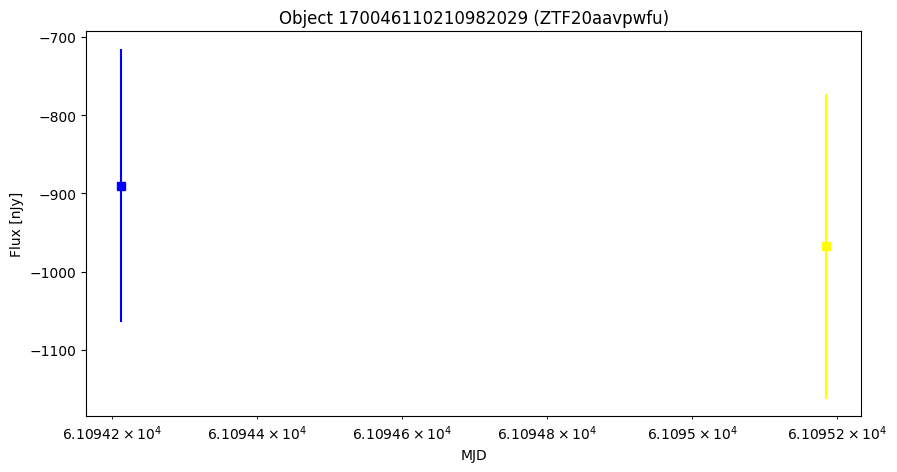

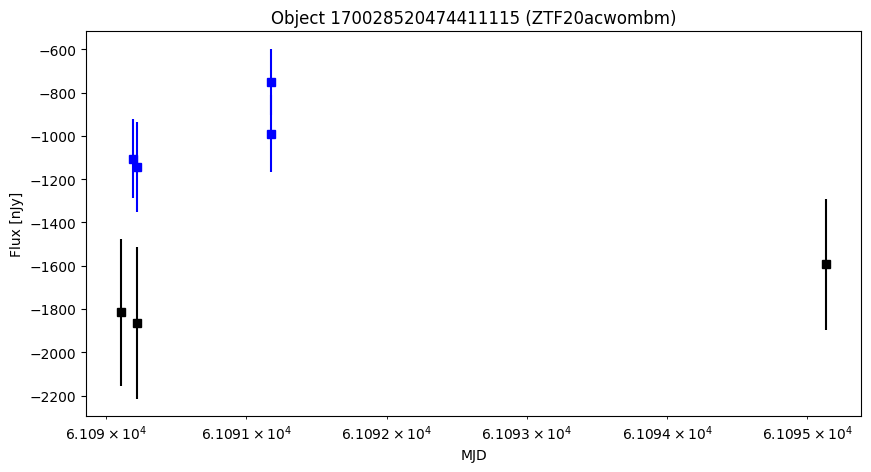

In [ ]:
for (ztf_oid, lsst_oid) in zip(df_snia_ztfxlsst.ztf_oid.unique(), df_snia_ztfxlsst.oid.unique()):
    fig, ax = plt.subplots(figsize=(10,5))
    lc_ztf  = df_ztf_all.loc[df_ztf_all.oid == ztf_oid]

    if ztf_oid == 'ZTF20acwombm':
        lsst_oid == 170032906288758949
        lc_lsst = df_ff_lsst_all[df_ff_lsst_all.oid == lsst_oid]
    else:
        lc_lsst = df_ff_lsst_all[df_ff_lsst_all.oid == lsst_oid]
    if len(lc_lsst) == 0:
        print(lsst_oid)
        lc_lsst = alerce_client.query_detections(lsst_oid, survey='lsst', format="pandas")

    for fid in lc_ztf.fid.unique():
        #print(fid)
        lc_fid = lc_ztf.loc[lc_ztf.fid == fid]
        #ax.errorbar(lc_fid.mjd, mag2fluxnjy(lc_fid.magpsf), yerr=mag_err_2_fluxnjy_err(lc_fid.sigmapsf, lc_fid.magpsf), fmt='o',
        #    color = 'green' if fid == 1 else 'red')
        #ax.errorbar(lc_fid.mjd, mag2fluxnjy(lc_fid.magpsf), yerr=mag_err_2_fluxnjy_err(lc_fid.sigmapsf, lc_fid.magpsf), fmt='o',
        #            color = 'green' if fid == 1 else 'red')

    for band in lc_lsst.band.unique():
        print(band)
        lc_band = lc_lsst.loc[lc_lsst.band == band]
        #lc_band = lc_band[lc_band.psfFlux > 0]
        #ax.scatter(lc_band.mjd, lc_band.psfFlux, s=10)
        #ax.errorbar(lc_band.mjd, fluxnjy2mag(lc_band.psfFlux), yerr=flux_err_2_mag_err(lc_band.psfFluxErr, lc_band.psfFlux), fmt='s',
        #            color = 'green' if band == 1 else 'red')
        ax.errorbar(lc_band.mjd, lc_band.psfFlux, yerr=lc_band.psfFluxErr, fmt='s',
            color = 'blue' if band == 1 else 'yellow' if band == 2 else 'black')


    ax.yaxis_inverted()
    ax.set_title(f'Object {lsst_oid} ({ztf_oid})')
    ax.set_ylabel('Flux [nJy]')
    ax.set_xlabel('MJD')

plt.show()

In [ ]:
all_objs_ztflsst.shape, all_objs_ztflsst.oid.nunique(), all_objs_ztflsst.columns
all_objs_ztflsst.to_pickle('./df_snia_ztfxlsst.pkl')

In [32]:
# Obtain the coordinates of two telescopes
coords_lsst = SkyCoord(ra=df_ff_lsst_all.ra.values*u.deg, dec=df_ff_lsst_all.dec.values*u.deg)
coords_ztf  = SkyCoord(ra=df_ztf_all.ra.values*u.deg, dec=df_ztf_all.dec.values*u.deg)

obj = SkyCoord(ra=51.060409*u.deg, dec=-27.333135*u.deg)

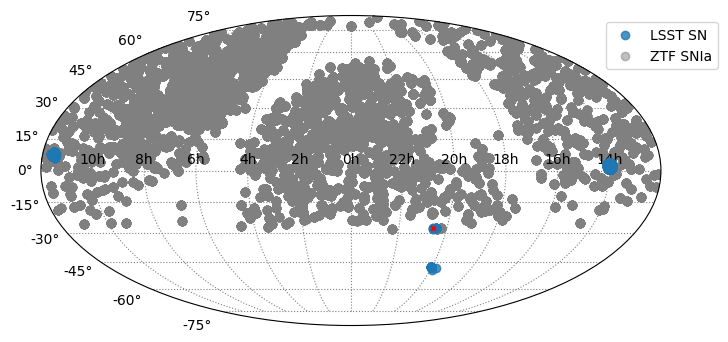

In [36]:
ra_lsst_rad  = coords_lsst.ra.wrap_at(180*u.deg).radian
dec_lsst_rad = coords_lsst.dec.radian

ra_ztf_rad  = coords_ztf.ra.wrap_at(180*u.deg).radian
dec_ztf_rad = coords_ztf.dec.radian

ra_obj_rad  = obj.ra.wrap_at(180*u.deg).radian
dec_obj_rad = obj.dec.radian

fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': 'mollweide'})
ax.scatter(ra_lsst_rad, dec_lsst_rad, alpha=0.8,zorder=2, label='LSST SN')
ax.scatter(ra_ztf_rad, dec_ztf_rad, color='gray', alpha=0.5,zorder=1, label='ZTF SNIa')
ax.scatter(ra_obj_rad, dec_obj_rad, marker='x', color='red', s=10,zorder=3)

ax.grid(True, linestyle=':', color='gray')
ax.legend(bbox_to_anchor = (0.9,1), loc='upper left')
ax.set_xticklabels(['10h', '8h', '6h', '4h', '2h', '0h', '22h', '20h', '18h', '16h', '14h'])

plt.show()

In [ ]:
#vecino más cercano, para cada objeto de lsst buscar en ztf
idx_nn, sep2d, _ = coords_lsst.match_to_catalog_sky(coords_ztf)

nearest = pd.DataFrame({
    "idx_lsst": np.arange(len(df_lsst)),
    "idx_ztf_nn": idx_nn,
    "sep_arcsec": sep2d.arcsec
})

print("\nSeparaciones al vecino más cercano:")
print(nearest["sep_arcsec"].describe())

display(nearest.sort_values("sep_arcsec").head(20))




Separaciones al vecino más cercano:
count       200.000000
mean      48489.631863
std       44604.848477
min        7427.920998
25%       12572.964045
50%       17064.721152
75%      104268.289600
max      122188.981614
Name: sep_arcsec, dtype: float64


,idx_lsst,idx_ztf_nn,sep_arcsec
85,85,4,7427.920998
116,116,4,7435.602200
174,174,4,7453.943039
42,42,4,7475.596401
122,122,4,7890.987234
139,139,4,8311.097586
103,103,4,8445.990687
59,59,4,8571.790371
120,120,4,8962.926816
152,152,4,8964.912383


In [ ]:

#¿CUÁNTOS MATCHES HABRÍA PARA DISTINTOS RADIOS?
for r in [1, 1.5, 2, 5, 10, 30, 50, 100, 300]:
    n = (nearest["sep_arcsec"] <= r).sum()
    print(f"radio = {r:>5} arcsec  ->  {n} matches")


radio =     1 arcsec  ->  0 matches
radio =   1.5 arcsec  ->  0 matches
radio =     2 arcsec  ->  0 matches
radio =     5 arcsec  ->  0 matches
radio =    10 arcsec  ->  0 matches
radio =    30 arcsec  ->  0 matches
radio =    50 arcsec  ->  0 matches
radio =   100 arcsec  ->  0 matches
radio =   300 arcsec  ->  0 matches


In [ ]:

#tablas de los más cercanos
nearest_out = nearest.copy()
nearest_out["ra_lsst"]  = df_lsst.loc[nearest_out["idx_lsst"], lsst_ra_col].values
nearest_out["dec_lsst"] = df_lsst.loc[nearest_out["idx_lsst"], lsst_dec_col].values
nearest_out["ra_ztf"]   = df_ztf.loc[nearest_out["idx_ztf_nn"], ztf_ra_col].values
nearest_out["dec_ztf"]  = df_ztf.loc[nearest_out["idx_ztf_nn"], ztf_dec_col].values

if "oid" in df_lsst.columns:
    nearest_out["oid_lsst"] = df_lsst.loc[nearest_out["idx_lsst"], "oid"].values
if "oid" in df_ztf.columns:
    nearest_out["oid_ztf"] = df_ztf.loc[nearest_out["idx_ztf_nn"], "oid"].values

display(nearest_out.sort_values("sep_arcsec").head(20))

,idx_lsst,idx_ztf_nn,sep_arcsec,ra_lsst,dec_lsst,ra_ztf,dec_ztf,oid_lsst,oid_ztf
85,85,4,7427.920998,187.316584,6.356475,188.91275,5.03938,170028526783169043,ZTF26aadsfln
116,116,4,7435.602200,187.644667,6.674888,188.91275,5.03938,170028527473131524,ZTF26aadsfln
174,174,4,7453.943039,187.157620,6.151154,188.91275,5.03938,170028527869493687,ZTF26aadsfln
42,42,4,7475.596401,187.341618,6.406234,188.91275,5.03938,170028537797935136,ZTF26aadsfln
122,122,4,7890.987234,187.752903,6.903258,188.91275,5.03938,170028537134710848,ZTF26aadsfln
139,139,4,8311.097586,186.984567,6.323327,188.91275,5.03938,170028534020440914,ZTF26aadsfln
103,103,4,8445.990687,187.577522,6.973569,188.91275,5.03938,170028531227033750,ZTF26aadsfln
59,59,4,8571.790371,186.860154,6.263016,188.91275,5.03938,170028528256942119,ZTF26aadsfln
120,120,4,8962.926816,186.733471,6.262326,188.91275,5.03938,170028535341646404,ZTF26aadsfln
152,152,4,8964.912383,186.896827,6.515466,188.91275,5.03938,170032916501364767,ZTF26aadsfln


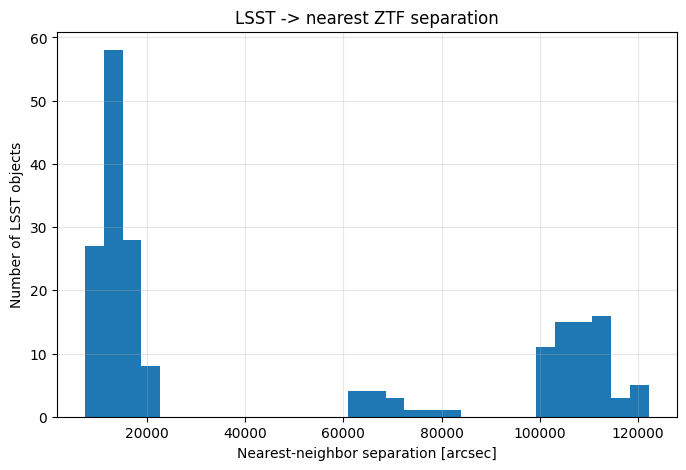

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(nearest["sep_arcsec"], bins=30)
plt.xlabel("Nearest-neighbor separation [arcsec]")
plt.ylabel("Number of LSST objects")
plt.title("LSST -> nearest ZTF separation")
plt.grid(alpha=0.3)
plt.show()

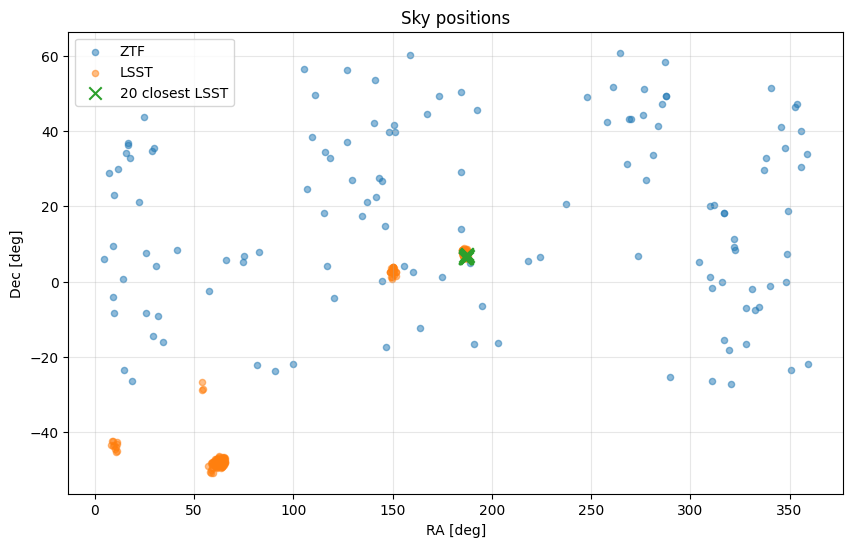

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(df_ztf[ztf_ra_col], df_ztf[ztf_dec_col], s=20, alpha=0.5, label="ZTF")
plt.scatter(df_lsst[lsst_ra_col], df_lsst[lsst_dec_col], s=20, alpha=0.5, label="LSST")

best20 = nearest_out.sort_values("sep_arcsec").head(20)
plt.scatter(best20["ra_lsst"], best20["dec_lsst"], s=80, marker="x", label="20 closest LSST")

plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title("Sky positions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [38]:
%%capture
!pip install astro-delight

In [39]:
from delight.delight import Delight

In [ ]:
df_ff_lsst_obj = {}
for oid in df_ff_lsst_all.oid.unique():
    df_ff_lsst_obj[oid] = df_ff_lsst_all[df_ff_lsst_all.oid == oid].oid.values[0]
    df_ff_lsst_obj[ra]  = df_ff_lsst_all[df_ff_lsst_all.oid == oid].ra.values[0]
    df_ff_lsst_obj[dec] = df_ff_lsst_all[df_ff_lsst_all.oid == oid].dec.values[0]

In [ ]:

dclient = Delight(delight_datadir, df_ff_lsst_all.oid, stats.meanra.to_numpy(), stats.meandec.to_numpy())